In [1]:
# Importamos pandas, la librería principal para manipulación de datos
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
from src.limpieza_datos import cargar_y_limpiar,limpiar_comercio,limpiar_moneda,mapa_codigos

In [2]:
# Cargamos el archivo CSV crudo en memoria como un DataFrame
raw_data = pd.read_csv('../data/raw_data/transacciones_fintech_2023.csv')

# .shape[0] devuelve el número total de filas del dataset
total_filas = raw_data.shape[0]
print(f'Total filas: {total_filas}')

Total filas: 50200


In [3]:
# Vista rápida de las primeras 5 filas para inspeccionar estructura y calidad inicial
print(raw_data.head())

      trx_id  user_id     transaction_date   merchant  amount currency  \
0  TRX012229      552             07-22-23     amazon   40.18      USD   
1  TRX004424      307  2023-09-04 08:00:00  Uber Eats   91.74      USD   
2  TRX017295      671           1696856400      Apple  105.17      COP   
3  TRX035515      472  2023-01-04 15:00:00      Apple  106.88      EUR   
4  TRX010446      172           18/03/2023    netflix    9.79      COP   

         status  
0        FAILED  
1       Pending  
2    completed   
3    completed   
4        FAILED  


In [4]:
# Tomamos una muestra aleatoria del 20% del dataset
# random_state=42 garantiza que la muestra sea reproducible en cada ejecución
# Solo inspeccionamos 'transaction_date' para detectar los distintos formatos presentes
muestra_csv = raw_data[['transaction_date']].sample(frac=0.2,random_state=42)
print(muestra_csv.head(20))

          transaction_date
5369   2023-08-24 00:00:00
14957  2023-12-16 18:00:00
41446  2023-01-08 11:00:00
26599  2023-03-18 17:00:00
36362             08-20-23
22500           03/05/2023
45637           1686956400
7161            11/05/2023
26978           23/01/2023
34281  2023-12-20 20:00:00
34842             09-29-23
30862           21/07/2023
672               01-09-23
46776           1689397200
36563             02-28-23
4844              03-04-23
3798            1683496800
5245            1675144800
29324  2023-03-17 23:00:00
27514           26/07/2023


In [5]:
# Ejecutamos la función maestra: carga el CSV y aplica limpieza de fechas y status internamente
ruta = '../data/raw_data/transacciones_fintech_2023.csv'
clean_data = cargar_y_limpiar(ruta)
# Verificamos que las fechas quedaron en formato datetime y el status normalizado
print(clean_data[['transaction_date','status']].head())

C:\Users\danny\OneDrive\Documentos\Valentina-Universidad\Otras cosas\Estudio\Programación\Python\Analisis de datos\Proyectos\Proyectos\17. fintech-data-wrangling\src\limpieza_datos.py:11: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  resultado = pd.to_datetime(fecha_texto, dayfirst=True ,errors="coerce")


     transaction_date     status
0 2023-07-22 00:00:00     Failed
1 2023-04-09 08:00:00    Pending
2 2023-10-09 13:00:00  Completed
3 2023-04-01 15:00:00  Completed
4 2023-03-18 00:00:00     Failed


In [6]:
# Aplicamos limpiar_comercio fila por fila sobre la columna 'merchant'
# Normaliza variantes del mismo comercio (ej: 'uber eats', 'UBER' → 'Uber')
clean_data['merchant'] = clean_data['merchant'].apply(limpiar_comercio)

print(clean_data['merchant'].head(20))

0        Amazon
1          Uber
2         Apple
3         Apple
4       Netflix
5        Amazon
6        Amazon
7     Starbucks
8        Amazon
9       Netflix
10       Amazon
11        Apple
12       Amazon
13    Starbucks
14        Apple
15      Netflix
16    Starbucks
17    Starbucks
18        Apple
19    Starbucks
Name: merchant, dtype: str


In [7]:
# Contamos cuántas transacciones tiene cada comercio después de la normalización
# Sirve para validar que no quedaron duplicados por variantes del mismo nombre
merchant_count = clean_data['merchant'].value_counts()
print((merchant_count))

merchant
Apple        11320
Uber         11153
Amazon       11065
Netflix       8347
Starbucks     8315
Name: count, dtype: int64


In [8]:
# .map() recorre cada valor de 'currency' y obtiene su tasa hacia USD usando limpiar_moneda
# Multiplicamos directamente por 'amount' para crear la columna convertida
# No sobreescribimos 'amount' ni 'currency' originales para mantener trazabilidad de auditoría
clean_data['amount_usd'] = clean_data['currency'].map(limpiar_moneda) * clean_data['amount']
print(clean_data['amount_usd'].head())

0     40.180000
1     91.740000
2      0.027344
3    115.644160
4      0.002545
Name: amount_usd, dtype: float64


In [9]:
# Filtramos solo las transacciones completadas y con monto mayor a 0 para cálculos precisos
ventas_completas = clean_data[(clean_data['status'] == 'Completed') & (clean_data['amount_usd'] > 0)]
print((ventas_completas.head(20)))

       trx_id  user_id    transaction_date   merchant  amount currency  \
2   TRX017295      671 2023-10-09 13:00:00      Apple  105.17      COP   
3   TRX035515      472 2023-04-01 15:00:00      Apple  106.88      EUR   
6   TRX042676      445 2023-08-15 00:00:00     Amazon   27.50      USD   
7   TRX002008      897 2023-07-09 00:00:00  Starbucks   48.42      EUR   
11  TRX016198      942 2023-06-16 13:00:00      Apple   24.19      COP   
16  TRX033036      360 2023-08-14 18:00:00  Starbucks    8.20      COP   
17  TRX029702      940 2023-05-21 20:00:00  Starbucks   27.89      USD   
18  TRX035495      250 2023-07-17 13:00:00      Apple   15.57      GBP   
21  TRX047552      352 2023-05-27 23:00:00    Netflix   28.24      USD   
22  TRX043055      495 2023-11-07 18:00:00    Netflix  144.47      GBP   
25  TRX047976      775 2023-06-24 20:00:00  Starbucks   11.46      USD   
30  TRX025447      238 2023-05-12 09:00:00    Netflix   43.51      USD   
34  TRX026339      603 2023-10-20 00:0

In [10]:
# Calculamos la suma total de las ventas válidas convertidas a USD
suma_total_usd = ventas_completas['amount_usd'].sum()
print(f" Suma Total$: {suma_total_usd:,.2f}")

 Suma Total$: 7,639,893.57


In [11]:
# Filtra las transacciones mayores a 10000 para detectar posibles fraudes
fraud_detected = clean_data[clean_data['amount_usd'] > 10000]
print(fraud_detected.head(20))

          trx_id  user_id    transaction_date   merchant     amount currency  \
2206   TRX009226      406 2023-02-09 22:00:00       Uber   50868.92      GBP   
4197   TRX034205      425 2023-05-29 00:00:00       Uber  236866.59      USD   
4785   TRX005664      386 2023-11-14 09:00:00       Uber  408762.17      EUR   
6334   TRX006186      336 2023-12-11 00:00:00       Uber  369854.13      USD   
9412   TRX019280      724 2023-04-27 19:00:00     Amazon  461434.86      GBP   
9558   TRX011236      499 2023-11-17 20:00:00      Apple  288119.23      EUR   
10067  TRX022483      531 2023-02-11 12:00:00      Apple  463894.63      USD   
11009  TRX000720      587 2023-02-18 11:00:00  Starbucks  410375.71      GBP   
11114  TRX030114      780 2023-05-26 03:00:00       Uber  236961.02      EUR   
11351  TRX012583      954 2023-08-07 00:00:00       Uber   93331.58      USD   
11504  TRX043070      933 2023-07-23 00:00:00    Netflix   96058.44      USD   
13355  TRX023848      735 2023-01-03 01:

**Respuesta 3.2: El ataque fraudulento de outliers es distribuido, atacando sistemáticamente a nuestros 5 comercios principales (Amazon con 10 intentos, Uber y Apple con 9 c/u, Starbucks con 7 y Netflix con 4). No es un ataque dirigido a un solo comercio.**

In [12]:
# .copy() previene el SettingWithCopyWarning al aislar clean_table de ventas_completas
clean_table = ventas_completas[ventas_completas['amount_usd'] <= 10000].copy()
print(clean_table.head(20))

       trx_id  user_id    transaction_date   merchant  amount currency  \
2   TRX017295      671 2023-10-09 13:00:00      Apple  105.17      COP   
3   TRX035515      472 2023-04-01 15:00:00      Apple  106.88      EUR   
6   TRX042676      445 2023-08-15 00:00:00     Amazon   27.50      USD   
7   TRX002008      897 2023-07-09 00:00:00  Starbucks   48.42      EUR   
11  TRX016198      942 2023-06-16 13:00:00      Apple   24.19      COP   
16  TRX033036      360 2023-08-14 18:00:00  Starbucks    8.20      COP   
17  TRX029702      940 2023-05-21 20:00:00  Starbucks   27.89      USD   
18  TRX035495      250 2023-07-17 13:00:00      Apple   15.57      GBP   
21  TRX047552      352 2023-05-27 23:00:00    Netflix   28.24      USD   
22  TRX043055      495 2023-11-07 18:00:00    Netflix  144.47      GBP   
25  TRX047976      775 2023-06-24 20:00:00  Starbucks   11.46      USD   
30  TRX025447      238 2023-05-12 09:00:00    Netflix   43.51      USD   
34  TRX026339      603 2023-10-20 00:0

In [13]:
# Extraemos el mes numérico y lo mapeamos a su nombre para facilitar lectura en agrupaciones y gráficos
clean_table['mes'] = clean_table['transaction_date'].dt.month.map(mapa_codigos)
print(clean_table.head(20))

       trx_id  user_id    transaction_date   merchant  amount currency  \
2   TRX017295      671 2023-10-09 13:00:00      Apple  105.17      COP   
3   TRX035515      472 2023-04-01 15:00:00      Apple  106.88      EUR   
6   TRX042676      445 2023-08-15 00:00:00     Amazon   27.50      USD   
7   TRX002008      897 2023-07-09 00:00:00  Starbucks   48.42      EUR   
11  TRX016198      942 2023-06-16 13:00:00      Apple   24.19      COP   
16  TRX033036      360 2023-08-14 18:00:00  Starbucks    8.20      COP   
17  TRX029702      940 2023-05-21 20:00:00  Starbucks   27.89      USD   
18  TRX035495      250 2023-07-17 13:00:00      Apple   15.57      GBP   
21  TRX047552      352 2023-05-27 23:00:00    Netflix   28.24      USD   
22  TRX043055      495 2023-11-07 18:00:00    Netflix  144.47      GBP   
25  TRX047976      775 2023-06-24 20:00:00  Starbucks   11.46      USD   
30  TRX025447      238 2023-05-12 09:00:00    Netflix   43.51      USD   
34  TRX026339      603 2023-10-20 00:0

In [14]:
# Filtramos y agrupamos las ventas mensuales específicamente para Amazon, asegurando todos los meses en orden
amazon_filtered_data = clean_table[clean_table['merchant'] == 'Amazon']
amazon_grouped_data = amazon_filtered_data.groupby('mes')['amount_usd'].sum()

amazon_grouped_data = amazon_grouped_data.reindex([mapa_codigos(i) for i in range(1, 13)])
print(amazon_grouped_data.apply(lambda x: f"${x:,.2f}"))

mes
Enero         $24,081.54
Febrero       $17,315.56
Marzo         $21,292.80
Abril         $21,083.87
Mayo          $22,282.32
Junio         $18,628.99
Julio         $24,186.73
Agosto        $17,821.69
Septiembre    $17,229.91
Octubre       $23,561.67
Noviembre     $20,371.28
Diciembre     $18,879.44
Name: amount_usd, dtype: str


**Respuesta 4.1: El mes en el que los usuarios gastaron más dinero en Amazon de forma regular en 2023 fue Julio, con un volumen de $24,186.73 USD.**

In [15]:
# Agrupamos las ventas totales por mes para analizar la tendencia de ingresos a nivel general
monthly_usd_total = clean_table.groupby('mes')['amount_usd'].sum()
monthly_usd_total = monthly_usd_total.reindex([mapa_codigos(i) for i in range(1, 13)])
print(monthly_usd_total.apply(lambda x: f"${x:,.2f}"))

mes
Enero         $102,310.11
Febrero        $82,186.37
Marzo          $94,893.82
Abril          $89,748.70
Mayo           $87,394.65
Junio          $81,458.12
Julio          $90,642.76
Agosto         $87,534.88
Septiembre     $86,740.79
Octubre        $98,056.54
Noviembre      $93,864.10
Diciembre      $97,386.09
Name: amount_usd, dtype: str


Text(0, 0.5, 'Ventas totales en US')

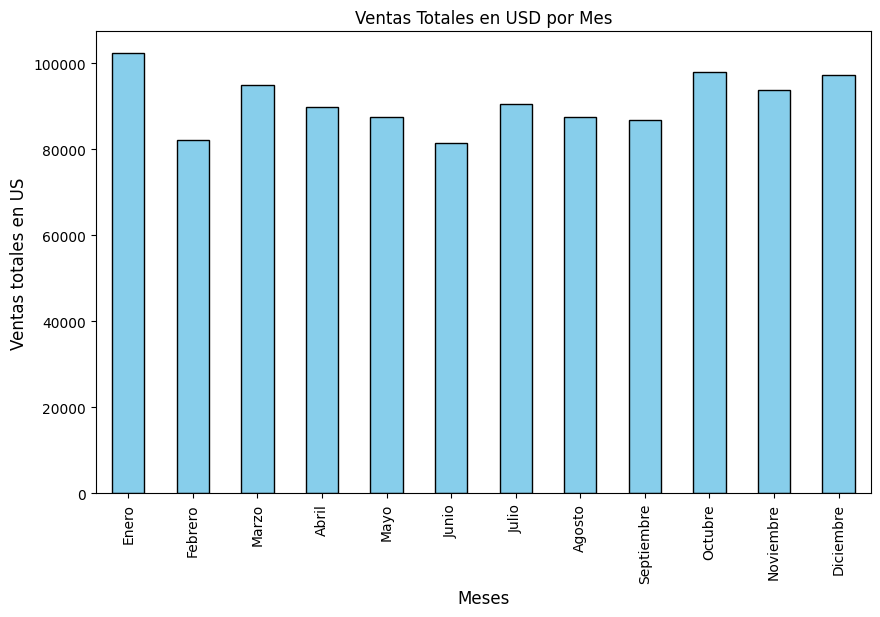

In [16]:
# Visualizamos la evolución mensual de las ventas totales en USD
monthly_usd_total.plot(
                kind='bar',
                figsize=(10, 6),
                color='skyblue',
                edgecolor='black',
                title='Ventas Totales en USD por Mes')


plt.xlabel('Meses', fontsize=12)
plt.ylabel('Ventas totales en US', fontsize=12)


In [17]:
# Strings repetitivos → enteros internos: menos memoria.
for col in ['status', 'merchant', 'currency']:
    clean_data[col] = clean_data[col].astype('category')

In [18]:
# float64 (8 bytes) → float32 (4 bytes): 50 % menos por valor.
for col in ['amount', 'amount_usd']:
    clean_data[col] = pd.to_numeric(clean_data[col], downcast='float')

In [19]:
# Analizamos cuánta memoria ocupa cada columna en bytes
# deep=True incluye el tamaño real de strings, no solo el puntero
print("\nUso de memoria por columna (bytes):")
print(clean_data.memory_usage(deep=True).sort_values(ascending=False))

# Convertimos el total a MB para una lectura más intuitiva
print(f"\nUso total del DataFrame: {clean_data.memory_usage(deep=True).sum() / (1024**2):.2f} MB")



Uso de memoria por columna (bytes):
trx_id              2911600
amount_usd           401600
user_id              401600
transaction_date     401600
amount               401600
merchant              50476
currency              50408
status                50369
Index                   132
dtype: int64

Uso total del DataFrame: 4.45 MB


In [21]:
clean_data.to_csv('../data/clean_data/transacciones_limpias_2023.csv', index=False)
print("Archivo exportado exitosamente.")

Archivo exportado exitosamente.
